[08:36:50] Initializing Normalizer


Inertial Fragment Matching happening...
Inertial Fragment Matching happened!
Fixed Fragment


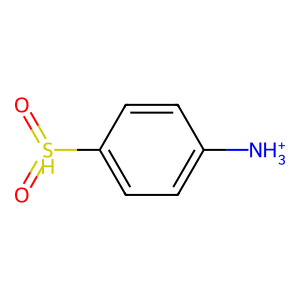

AVERAGE SHAPE SIMILARITY - 0.6340000000000001
VALID SAMPLES - 75.0 %


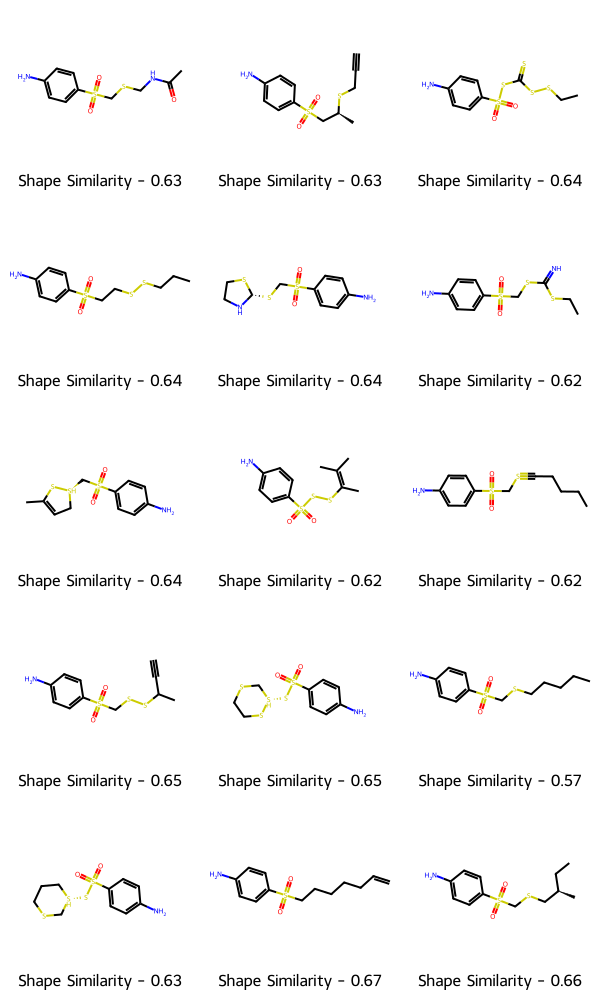

In [1]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw

from src.mlconfgen import evaluate_samples, MLConformerGenerator
from src.mlconfgen.inertial_fragment_matching import ff_inertial_fragment_matching, predict_bonds_openbabel
from src.mlconfgen.utils.mol_utils import prepare_masks, redefine_bonds, prepare_adj_mat_seer_input
from src.mlconfgen.utils.standardizer import standardize_mol

RDLogger.DisableLog('rdApp.*')

device = "mps"

generator = MLConformerGenerator(
                                 edm_weights="./licensed_edm_moi_chembl_6_39_final.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device=device,
                                 diffusion_steps=100, # Light generation for debugging
                                )

merger = MLConformerGenerator(
                                 edm_weights="./edm_moi_chembl_15_39.pt",
                                 adj_mat_seer_weights="./adj_mat_seer_chembl_15_39.pt",
                                 device=device,
                                 diffusion_steps=100, # Light generation for debugging
                                )

# ref_mol = Chem.MolFromMolFile('38_atoms_example.mol')
ref_mol = Chem.MolFromMolFile('./assets/demo_files/ceyyag.mol')

n_atoms = ref_mol.GetNumHeavyAtoms()

print("Inertial Fragment Matching happening...")

N_SAMPLES = 20

final_mols, fixed_fragment = ff_inertial_fragment_matching(
                                    ref_mol=ref_mol,
                                    generator=generator,
                                    merger=merger,
                                    n_samples=N_SAMPLES,
                                    variance=0,
                                    resample_steps=0,
                                    blend_power=2,
                                    merging_diffusion_level=20,
                                    min_frag_size=6,
                                    max_frag_size=15,
                                    max_iter=200,
                                    verbose=False,
    
)

print("Inertial Fragment Matching happened!")


obabel_mols = []

# Switched to deterministic bond prediction
for mol in final_mols:
    f_mol = predict_bonds_openbabel(mol, optimize_geometry=False)
    if f_mol:
        obabel_mols.append(f_mol)

_, std_samples = evaluate_samples(ref_mol, obabel_mols)

print("Fixed Fragment")
ff_img = Draw.MolToImage(Chem.MolFromSmiles(Chem.MolToSmiles(fixed_fragment)), size=(300, 300))
display(ff_img)
# Display results
mols = []
legends = []
average_shape_similarity = 0
for sample in std_samples:
    mol = Chem.MolFromMolBlock(sample['mol_block'])
    mol = Chem.MolFromSmiles(Chem.MolToSmiles(mol))
    mol.SetProp("Shape_Tanimoto", str(sample['shape_tanimoto']))
    mols.append(mol)
    legends.append(f"Shape Similarity - {round(sample['shape_tanimoto'], 2)}")
    average_shape_similarity += round(sample['shape_tanimoto'], 2)

average_shape_similarity = average_shape_similarity / len(std_samples)
print(f"AVERAGE SHAPE SIMILARITY - {average_shape_similarity}")
print(f"VALID SAMPLES - {round(len(std_samples) / N_SAMPLES, 2) * 100} %")
    
Draw.MolsToGridImage(mols, legends=legends)